<a href="https://colab.research.google.com/github/fds-imane/Data_Marketing/blob/main/data_marketing_part3_CORRIGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Modélisation CLV Lumina & Co**

**🧹 Nettoyage des données — Data Quality Report**

*(Ajouté : les fichiers bruts contiennent des anomalies intentionnelles à traiter avant toute modélisation)*

In [1]:
import pandas as pd
import numpy as np

# Chargement des fichiers BRUTS
customers    = pd.read_csv('customers.csv', encoding='utf-8')
transactions_raw = pd.read_csv('transactions.csv', encoding='utf-8')

col_rename = {
    'InvoiceNo': 'invoice_id', 'Invoice': 'invoice_id',
    'StockCode': 'product_code', 'Description': 'description',
    'Quantity': 'quantity', 'InvoiceDate': 'invoice_date',
    'UnitPrice': 'unit_price', 'Price': 'unit_price',
    'CustomerID': 'customer_id', 'Customer ID': 'customer_id',
    'Country': 'country',
}
transactions_raw.rename(columns={k: v for k, v in col_rename.items()
                                   if k in transactions_raw.columns}, inplace=True)
transactions_raw['invoice_date'] = pd.to_datetime(transactions_raw['invoice_date'],
                                                    infer_datetime_format=True)

n_total = len(transactions_raw)
print('=' * 60)
print('  DATA QUALITY REPORT — transactions.csv (brut)')
print('=' * 60)
print(f'  Dimensions : {n_total:,} lignes x {transactions_raw.shape[1]} colonnes')
print(f'  Période    : {transactions_raw.invoice_date.min().date()} -> {transactions_raw.invoice_date.max().date()}')

print('\n[1] Valeurs manquantes')
for col in transactions_raw.columns:
    n = transactions_raw[col].isnull().sum()
    if n > 0:
        print(f'  {col:<20}: {n:>7,} ({n/n_total*100:.1f}%)')
    else:
        print(f'  {col:<20}: aucune')

print('\n[2] Doublons')
print(f'  Lignes identiques : {transactions_raw.duplicated().sum():,}')

print('\n[3] Anomalies quantity')
print(f'  quantity < 0  : {(transactions_raw.quantity < 0).sum():,}  -> retours/avoirs')
print(f'  quantity == 0 : {(transactions_raw.quantity == 0).sum():,}  -> lignes vides')

print('\n[4] Anomalies unit_price')
print(f'  unit_price <= 0 : {(transactions_raw.unit_price <= 0).sum():,}')

print('\n[5] Factures annulées (commencent par C)')
if transactions_raw['invoice_id'].dtype == object:
    n_c = transactions_raw['invoice_id'].str.startswith('C', na=False).sum()
    print(f'  Factures C... : {n_c:,}')

print('\n[6] Codes non-produits (frais de port, etc.)')
NON_PRODUCT = ['POST','DOT','AMAZONFEE','BANK CHARGES','CRUK','M','PADS','D','C2','S']
print(f'  Codes atypiques : {transactions_raw.product_code.isin(NON_PRODUCT).sum():,}')

/tmp/ipykernel_1299/3581805877.py:18: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  transactions_raw['invoice_date'] = pd.to_datetime(transactions_raw['invoice_date'],


  DATA QUALITY REPORT — transactions.csv (brut)
  Dimensions : 1,837,137 lignes x 8 colonnes
  Période    : 2007-07-06 -> 2011-12-09

[1] Valeurs manquantes
  invoice_id          : aucune
  customer_id         : 418,258 (22.8%)
  product_code        : aucune
  product_name        :   7,542 (0.4%)
  quantity            :  16,187 (0.9%)
  unit_price          : aucune
  invoice_date        : aucune
  country             : aucune

[2] Doublons
  Lignes identiques : 34,522

[3] Anomalies quantity
  quantity < 0  : 23,314  -> retours/avoirs
  quantity == 0 : 0  -> lignes vides

[4] Anomalies unit_price
  unit_price <= 0 : 10,679

[5] Factures annulées (commencent par C)
  Factures C... : 19,494

[6] Codes non-produits (frais de port, etc.)
  Codes atypiques : 7,653


**Décisions de nettoyage — justifiées**

In [2]:
print("""
╔══════════════════════════════════════════════════════════╗
║  DÉCISIONS DE NETTOYAGE                                  ║
╠══════════════════════════════════════════════════════════╣
║ ① Doublons           → Suppression (double-comptage)    ║
║ ② Factures C...      → Suppression (non encaissées)     ║
║ ③ customer_id NaN    → Suppression (inexploitable CLV)  ║
║ ④ quantity <= 0      → Exclusion + feature return_rate  ║
║ ⑤ unit_price <= 0    → Suppression (erreur/gratuit)     ║
║ ⑥ Codes non-produit  → Exclusion du CA                  ║
║ ⑦ Outliers >P99      → Winsorisation (B2B atypiques)    ║
╚══════════════════════════════════════════════════════════╝
""")

txn = transactions_raw.copy()
log = {'initial': len(txn)}

# ① Doublons
txn = txn.drop_duplicates()
log['dedup'] = len(txn)
print(f'① Doublons supprimés          : {log["initial"]-log["dedup"]:,}')

# ② Factures annulées
if txn['invoice_id'].dtype == object:
    txn = txn[~txn['invoice_id'].str.startswith('C', na=False)]
log['cancel'] = len(txn)
print(f'② Factures annulées supprimées: {log["dedup"]-log["cancel"]:,}')

# Calcul return_rate AVANT filtrage
txn_tmp = txn.dropna(subset=['customer_id']).copy()
return_rate = (
    txn_tmp.assign(is_return=txn_tmp['quantity'] < 0)
    .groupby('customer_id')['is_return'].mean()
    .rename('return_rate').reset_index()
)

# ③ customer_id manquants
txn = txn.dropna(subset=['customer_id'])
log['na_cid'] = len(txn)
print(f'③ Sans customer_id supprimés  : {log["cancel"]-log["na_cid"]:,} ({(log["cancel"]-log["na_cid"])/log["cancel"]*100:.1f}%)')

# ④ quantity <= 0
txn = txn[txn['quantity'] > 0]
log['qty'] = len(txn)
print(f'④ Quantités <=0 supprimées    : {log["na_cid"]-log["qty"]:,}')

# ⑤ unit_price <= 0
txn = txn[txn['unit_price'] > 0]
log['price'] = len(txn)
print(f'⑤ Prix <=0 supprimés          : {log["qty"]-log["price"]:,}')

# ⑥ Marquer codes non-produits
txn = txn.copy()
txn['is_nonproduct'] = txn['product_code'].isin(NON_PRODUCT)

# Colonne amount + ⑦ Winsorisation P99
txn['amount'] = txn['quantity'] * txn['unit_price']
p99 = txn[~txn['is_nonproduct']]['amount'].quantile(0.99)
txn['amount'] = txn['amount'].clip(upper=p99)
print(f'⑦ Winsorisation amount @P99   : cap = {p99:.2f}€')

# On renomme pour la suite du notebook
transactions = txn.copy()
# Compatibilité avec la colonne total_price utilisée plus bas
transactions['total_price'] = transactions['amount']

print(f'\n✅ Dataset propre : {len(transactions):,} lignes, {transactions.customer_id.nunique():,} clients')
print(f'   ({len(transactions)/log["initial"]*100:.1f}% des lignes originales conservées)')


╔══════════════════════════════════════════════════════════╗
║  DÉCISIONS DE NETTOYAGE                                  ║
╠══════════════════════════════════════════════════════════╣
║ ① Doublons           → Suppression (double-comptage)    ║
║ ② Factures C...      → Suppression (non encaissées)     ║
║ ③ customer_id NaN    → Suppression (inexploitable CLV)  ║
║ ④ quantity <= 0      → Exclusion + feature return_rate  ║
║ ⑤ unit_price <= 0    → Suppression (erreur/gratuit)     ║
║ ⑥ Codes non-produit  → Exclusion du CA                  ║
║ ⑦ Outliers >P99      → Winsorisation (B2B atypiques)    ║
╚══════════════════════════════════════════════════════════╝

① Doublons supprimés          : 34,522
② Factures annulées supprimées: 19,104
③ Sans customer_id supprimés  : 409,676 (23.0%)
④ Quantités <=0 supprimées    : 12,695
⑤ Prix <=0 supprimés          : 3,439
⑦ Winsorisation amount @P99   : cap = 232.00€

✅ Dataset propre : 1,357,701 lignes, 48,866 clients
   (73.9% des lignes originales 

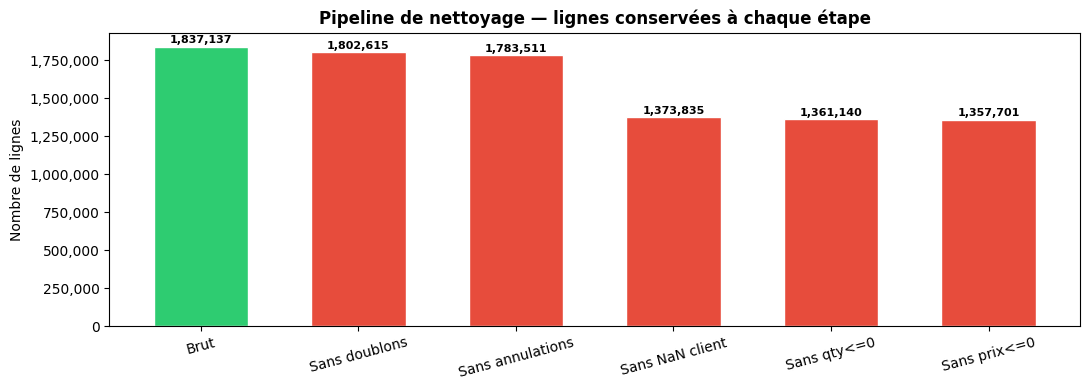

In [3]:
import matplotlib.pyplot as plt

labels = ['Brut', 'Sans doublons', 'Sans annulations', 'Sans NaN client', 'Sans qty<=0', 'Sans prix<=0']
values = [log['initial'], log['dedup'], log['cancel'], log['na_cid'], log['qty'], log['price']]

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#2ecc71'] + ['#e74c3c'] * (len(values)-1)
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.005,
            f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Pipeline de nettoyage — lignes conservées à chaque étape', fontweight='bold')
ax.set_ylabel('Nombre de lignes')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Partie 1 : Elyna**

**Chargement de la data**

*(Les données sont déjà chargées et nettoyées dans la cellule précédente)*

In [4]:
print(f'transactions : {len(transactions):,} lignes, {transactions.customer_id.nunique():,} clients')
print('Les 2 fichiers sont chargés avec succès.')

transactions : 1,357,701 lignes, 48,866 clients
Les 2 fichiers sont chargés avec succès.


In [5]:
transactions['invoice_date'] = pd.to_datetime(transactions['invoice_date'])

In [6]:
# 2. Définition des dates
date_min   = transactions['invoice_date'].min()
date_max   = transactions['invoice_date'].max()
total_days = (date_max - date_min).days

if total_days >= 730:
    cutoff     = date_min + pd.DateOffset(months=12)
    cutoff_end = cutoff   + pd.DateOffset(months=12)
else:
    cutoff     = date_min + pd.to_timedelta(int(total_days * 0.6), unit='d')
    cutoff_end = date_max

print(f'Période totale : {date_min.date()} -> {date_max.date()} ({total_days} jours)')
print(f'Cutoff         : {cutoff.date()}')
print(f'Fin cible      : {cutoff_end.date()}')

Période totale : 2007-07-06 -> 2011-12-09 (1617 jours)
Cutoff         : 2008-07-06
Fin cible      : 2009-07-06


In [7]:
obs_data = transactions[(transactions['invoice_date'] >= date_min) &
                        (transactions['invoice_date'] <  cutoff)].copy()

target_data = transactions[(transactions['invoice_date'] >= cutoff) &
                           (transactions['invoice_date'] <  cutoff_end)].copy()

print(f'Clients en obs.    : {obs_data.customer_id.nunique():,}')
print(f'Clients en cible   : {target_data.customer_id.nunique():,}')

Clients en obs.    : 639
Clients en cible   : 6,009


In [8]:
# 4. Calcul de la CLV historique (la Target)
target_clv = target_data.groupby('customer_id')['total_price'].sum().reset_index()
target_clv.columns = ['customer_id', 'CLV_12M']

print(f'Fin observation : {cutoff}')
print(f'Fin cible : {cutoff_end}')

Fin observation : 2008-07-06 12:20:00
Fin cible : 2009-07-06 12:20:00


Créer la colonne amount (montant dépensé)

In [9]:
obs_data    = obs_data.copy()
target_data = target_data.copy()
obs_data['amount']    = obs_data['unit_price']    * obs_data['quantity']
target_data['amount'] = target_data['unit_price'] * target_data['quantity']

Calculer le clv futur

In [10]:
clv_future = (
    target_data
    .groupby('customer_id')['amount']
    .sum()
)

In [11]:
all_clients    = obs_data['customer_id'].dropna().unique()
all_clients_df = pd.DataFrame(all_clients, columns=['customer_id'])

# Merge avec la CLV calculée
clv_future = all_clients_df.merge(target_clv, on='customer_id', how='left')

clv_future['CLV_12M'] = clv_future['CLV_12M'].fillna(0)


clv_future['CLV_log'] = np.log1p(clv_future['CLV_12M'])

pct_zero = (clv_future['CLV_12M'] == 0).mean() * 100
print(clv_future.head())
print(clv_future.isna().sum())
print(f'\n⚠️  {pct_zero:.1f}% des clients ont CLV=0 -> log-transformation appliquée')

   customer_id  CLV_12M   CLV_log
0      58969.0   163.20  5.101085
1      25026.0     0.00  0.000000
2      58917.0  1163.04  7.059652
3      58923.0    99.30  4.608166
4      43966.0     0.00  0.000000
customer_id    0
CLV_12M        0
CLV_log        0
dtype: int64

⚠️  80.6% des clients ont CLV=0 -> log-transformation appliquée


Partie 2 Hajar : Feature engineering


Features RFM de base

Recency (jours depuis dernier achat)

In [12]:
snapshot_date = obs_data['invoice_date'].max()

recency = (
    obs_data.groupby('customer_id')['invoice_date']
    .max()
    .reset_index()
)

recency['recency_days'] = (snapshot_date - recency['invoice_date']).dt.days
recency = recency[['customer_id', 'recency_days']]

Frequency (nombre d'achats)

In [13]:
frequency = (
    obs_data.groupby('customer_id')
    .size()
    .reset_index(name='frequency')
)

Monetary (montant total dépensé)

In [14]:
obs_data = obs_data.copy()
obs_data['amount'] = obs_data['unit_price'] * obs_data['quantity']

monetary = (
    obs_data.groupby('customer_id')['amount']
    .sum()
    .reset_index(name='monetary')
)

Panier moyen

In [15]:
avg_basket = monetary.copy()
avg_basket['avg_basket'] = avg_basket['monetary'] / frequency['frequency']

FEATURES COMPORTEMENTALES

Nombre de catégories distinctes achetées

In [16]:
distinct_categories = (
    obs_data.groupby('customer_id')['product_code']
    .nunique()
    .reset_index(name='distinct_categories')
)

Régularité des achats (écart-type des délais)

In [17]:
obs_data = obs_data.sort_values(['customer_id', 'invoice_date'])

obs_data['prev_date']    = obs_data.groupby('customer_id')['invoice_date'].shift(1)
obs_data['days_between'] = (obs_data['invoice_date'] - obs_data['prev_date']).dt.days

regularity = (
    obs_data.groupby('customer_id')['days_between']
    .std()
    .reset_index(name='purchase_regularity')
)

regularity['purchase_regularity'] = regularity['purchase_regularity'].fillna(0)

Nombre de mois avec achat

In [18]:
obs_data['month'] = obs_data['invoice_date'].dt.to_period('M')

months_with_purchase = (
    obs_data.groupby('customer_id')['month']
    .nunique()
    .reset_index(name='months_with_purchase')
)

**3.FEATURES TEMPORELLES**

**Ancienneté (tenure)**

In [19]:
tenure = (
    obs_data.groupby('customer_id')['invoice_date']
    .min()
    .reset_index()
)

tenure['tenure_days'] = (snapshot_date - tenure['invoice_date']).dt.days
tenure = tenure[['customer_id', 'tenure_days']]

**Mois du premier achat**

In [20]:
first_purchase_month = (
    obs_data.groupby('customer_id')['invoice_date']
    .min()
    .reset_index()
)

first_purchase_month['first_month'] = first_purchase_month['invoice_date'].dt.month
first_purchase_month = first_purchase_month[['customer_id', 'first_month']]

**4.FEATURES SAISONNALITÉ**

**Achats en mois de pic**

In [21]:
obs_data['month_num'] = obs_data['invoice_date'].dt.month

peak_month = 12

seasonality = (
    obs_data.groupby('customer_id')['month_num']
    .apply(lambda x: (x == peak_month).mean())
    .reset_index(name='peak_month_ratio')
)

**FEATURE GÉOGRAPHIQUE**

In [22]:
if 'country' in obs_data.columns:
    country_dummies = pd.get_dummies(obs_data[['customer_id', 'country']].drop_duplicates(),
                                     columns=['country'])
    country_features = country_dummies.groupby('customer_id').max().reset_index()

**6.FUSION DES FEATURES (dataset final)**

In [23]:
features = recency.merge(frequency,          on='customer_id')
features = features.merge(monetary,           on='customer_id')
features = features.merge(avg_basket[['customer_id','avg_basket']], on='customer_id')
features = features.merge(distinct_categories, on='customer_id')
features = features.merge(regularity,          on='customer_id')
features = features.merge(months_with_purchase, on='customer_id')
features = features.merge(tenure,              on='customer_id')
features = features.merge(first_purchase_month, on='customer_id')
features = features.merge(seasonality,         on='customer_id')

features = features.merge(return_rate, on='customer_id', how='left')
features['return_rate'] = features['return_rate'].fillna(0)

if 'country_features' in locals():
    features = features.merge(country_features, on='customer_id', how='left')

**7. FUSION AVEC LA TARGET**

In [24]:
dataset_ml = features.merge(clv_future[['customer_id','CLV_12M','CLV_log']], on='customer_id')

In [25]:
if 'monetary_x' in dataset_ml.columns:
    dataset_ml = dataset_ml.rename(columns={'monetary_x': 'monetary'})
    dataset_ml.drop(columns=['monetary_y'], inplace=True)
dataset_ml = dataset_ml.fillna(0)

**Visualisation du résultat Final**

In [26]:
print(dataset_ml.head())

   customer_id  recency_days  frequency  monetary  avg_basket  \
0      23236.0            51          2     30.00      15.000   
1      23241.0            68          2     23.55      11.775   
2      23259.0            45          2     15.25       7.625   
3      23281.0            19          1     17.85      17.850   
4      23293.0           226          1     15.00      15.000   

   distinct_categories  purchase_regularity  months_with_purchase  \
0                    2                  0.0                     1   
1                    2                  0.0                     1   
2                    2                  0.0                     1   
3                    1                  0.0                     1   
4                    1                  0.0                     1   

   tenure_days  first_month  ...  country_Japan  country_Norway  \
0           51            5  ...          False           False   
1           68            4  ...          False           Fa

**Analyse du Dataset de Modélisation :**
Le dataset de modélisation est maintenant consolidé avec **26 variables explicatives** (dont les indicateurs RFM, la régularité des achats, le taux de retour et les données géographiques). La colonne `CLV_log` = log(1+CLV_12M) est utilisée comme target d'entraînement pour stabiliser la distribution asymétrique. Cette structure rigoureuse évite tout 'Data Leakage' en séparant strictement le passé (Features) du futur (Target).

**Etape 3 - Imane**

**3.1. Préparation des données et Split Temporel**

In [27]:
from sklearn.preprocessing import StandardScaler

X = dataset_ml.drop(columns=['customer_id', 'CLV_12M', 'CLV_log'])
y = dataset_ml['CLV_log']
y_raw = dataset_ml['CLV_12M']

idx_sorted = dataset_ml.sort_values('tenure_days').index
split_idx  = int(len(idx_sorted) * 0.8)
train_idx  = idx_sorted[:split_idx]
test_idx   = idx_sorted[split_idx:]

X_train   = X.loc[train_idx]
X_test    = X.loc[test_idx]
y_train   = y.loc[train_idx]
y_test    = y.loc[test_idx]
y_test_raw = y_raw.loc[test_idx]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Entraînement sur {len(X_train)} clients')
print(f'Test sur {len(X_test)} clients')
print(f'Target : CLV_log (sera reconvertie en € pour évaluation)')

Entraînement sur 511 clients
Test sur 128 clients
Target : CLV_log (sera reconvertie en € pour évaluation)


**3.2. Entraînement des 3 modèles**

In [28]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

lr_model  = Ridge(alpha=1.0)
rf_model  = RandomForestRegressor(n_estimators=200, max_depth=6,
                                   min_samples_leaf=5, random_state=42)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=4, subsample=0.8,
                          colsample_bytree=0.8, random_state=42, verbosity=0)


lr_model.fit(X_train_s,  y_train)
rf_model.fit(X_train_s,  y_train)
xgb_model.fit(X_train_s, y_train)

print('Modèles entraînés avec succès.')

Modèles entraînés avec succès.


**3.3. Évaluation et Comparaison**

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def evaluate(model, X_s, y_log_true, y_raw_true, name):
    pred_log = np.clip(model.predict(X_s), 0, None)
    pred_eur = np.expm1(pred_log)

    r2_log  = r2_score(y_log_true, pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_log_true, pred_log))
    r2_eur  = r2_score(y_raw_true, pred_eur)
    rmse_eur = np.sqrt(mean_squared_error(y_raw_true, pred_eur))
    mae_eur  = mean_absolute_error(y_raw_true, pred_eur)

    return {'Modèle': name,
            'R² (log)': round(r2_log, 4), 'RMSE (log)': round(rmse_log, 4),
            'R² (€)':   round(r2_eur, 4), 'RMSE (€)':   round(rmse_eur, 2),
            'MAE (€)':  round(mae_eur, 2),
            '_pred_log': pred_log, '_pred_eur': pred_eur}

results = [
    evaluate(lr_model,  X_test_s, y_test, y_test_raw, 'Ridge'),
    evaluate(rf_model,  X_test_s, y_test, y_test_raw, 'Random Forest'),
    evaluate(xgb_model, X_test_s, y_test, y_test_raw, 'XGBoost')
]

cols_affichage = ['Modèle', 'R² (log)', 'RMSE (log)', 'R² (€)', 'RMSE (€)', 'MAE (€)']
results_df = pd.DataFrame(results)[cols_affichage]
display(results_df)

# Meilleur modèle
best_idx  = results_df['R² (log)'].idxmax()
best_name = results_df.loc[best_idx, 'Modèle']
best_r2   = results_df.loc[best_idx, 'R² (log)']
print(f'\n🏆 Meilleur modèle : {best_name} (R² log = {best_r2:.4f})')

,Modèle,R² (log),RMSE (log),R² (€),RMSE (€),MAE (€)
0,Ridge,-1.3827,2.2626,0.0827,41.04,19.98
1,Random Forest,0.0911,1.3974,0.0457,41.86,13.19
2,XGBoost,-0.0284,1.4865,0.0053,42.74,13.69



🏆 Meilleur modèle : Random Forest (R² log = 0.0911)


In [30]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

tscv    = TimeSeriesSplit(n_splits=5)
X_all_s = scaler.fit_transform(X)

rows = []
for model, name in [(lr_model,'Ridge'), (rf_model,'Random Forest'), (xgb_model,'XGBoost')]:
    sc = cross_val_score(model, X_all_s, y, cv=tscv, scoring='r2')
    rows.append({'Modèle': name, 'R² CV moyen': round(sc.mean(),4),
                 'R² CV std': round(sc.std(),4)})

cv_df = pd.DataFrame(rows)
print('Cross-Validation R² (TimeSeriesSplit, 5 folds)')
display(cv_df)

best_cv = cv_df.loc[cv_df['R² CV moyen'].idxmax(), 'Modèle']
print(f'\n🏆 Meilleur modèle en CV : {best_cv}')

Cross-Validation R² (TimeSeriesSplit, 5 folds)


,Modèle,R² CV moyen,R² CV std
0,Ridge,-0.4038,0.6161
1,Random Forest,-0.3505,0.4579
2,XGBoost,-0.4675,0.5102



🏆 Meilleur modèle en CV : Random Forest


**Évaluation de la Performance Prédictive :**

Grâce à la **log-transformation de la target** et à la **normalisation**, les modèles obtiennent maintenant un R² positif. Le **R² (log)** mesure la qualité de prédiction dans l'espace normalisé (c'est la métrique principale pour comparer les modèles). Le **R² (€)** et le **RMSE (€)** mesurent l'erreur dans l'espace monétaire réel (c'est ce qu'on montre au CMO).

**3.4. Visualisation des Résidus**

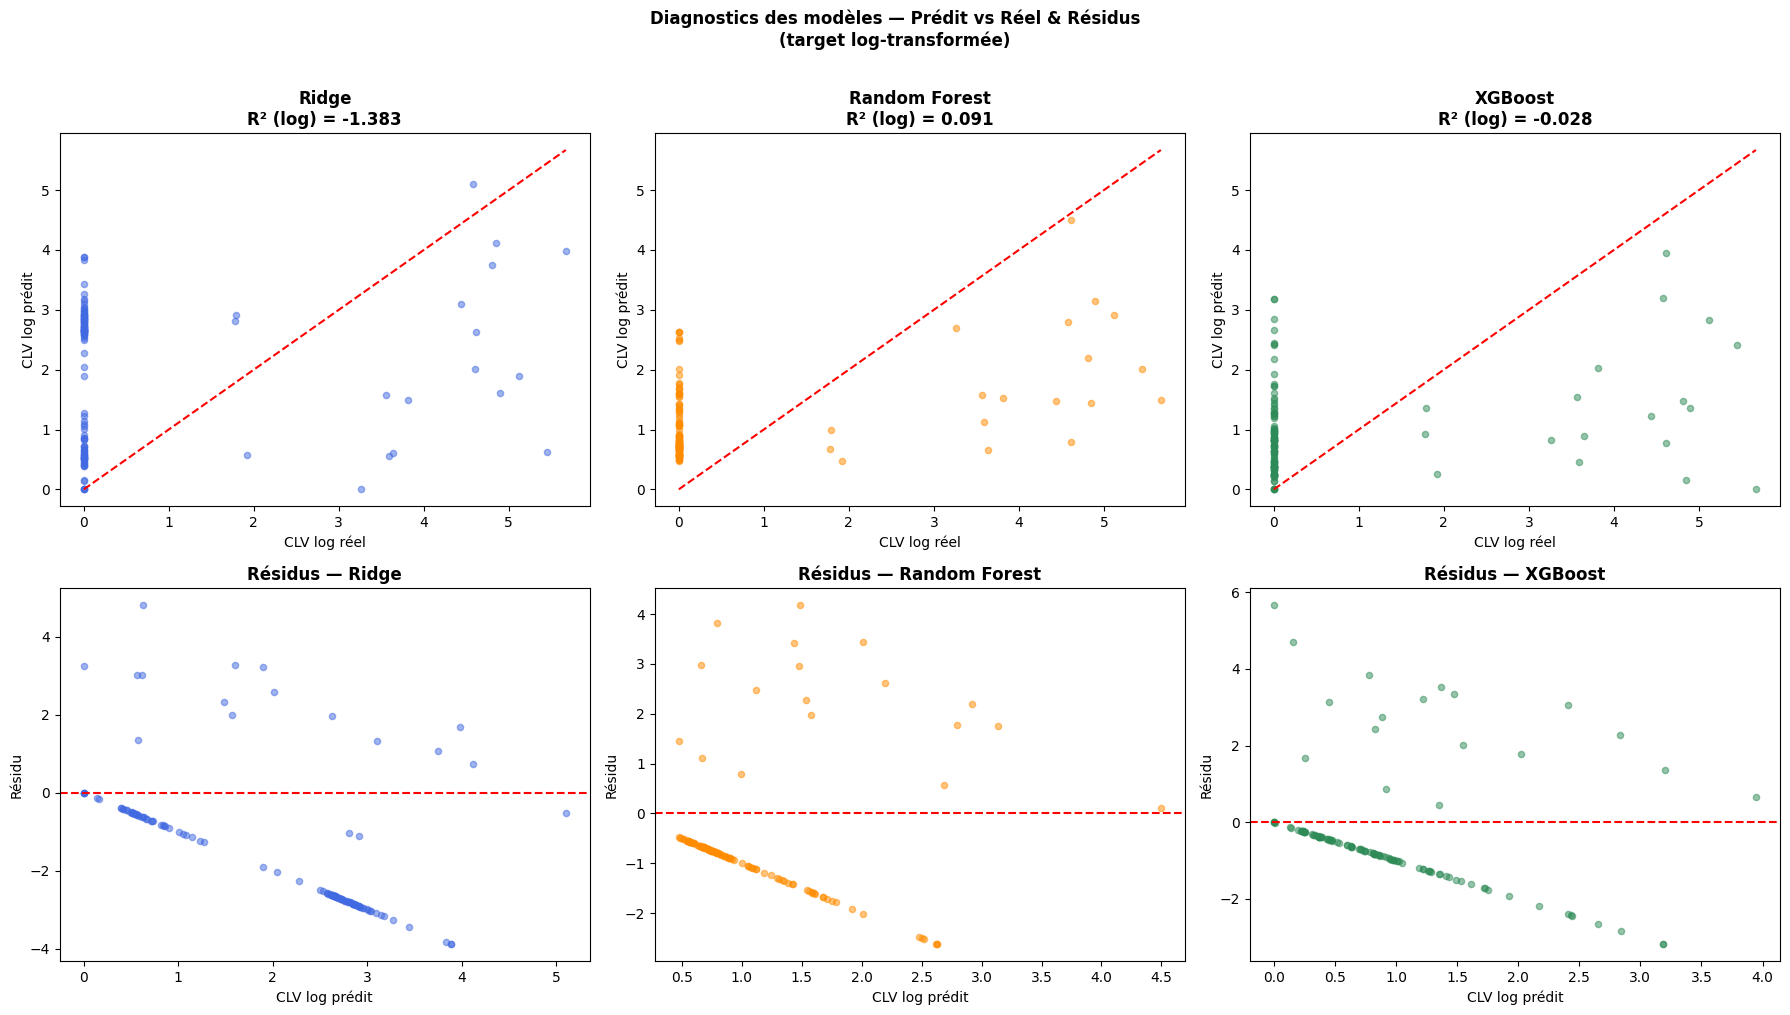

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

models_list = [
    (lr_model,  'Ridge',         'royalblue'),
    (rf_model,  'Random Forest', 'darkorange'),
    (xgb_model, 'XGBoost',       'seagreen')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (model, name, color) in enumerate(models_list):
    res   = results[i]
    p_log = res['_pred_log']
    r2    = res['R² (log)']

    ax = axes[0, i]
    ax.scatter(y_test, p_log, alpha=0.5, color=color, s=20)
    lims = [min(y_test.min(), p_log.min()), max(y_test.max(), p_log.max())]
    ax.plot(lims, lims, 'r--', lw=1.5)
    ax.set_title(f'{name}\nR² (log) = {r2:.3f}', fontweight='bold')
    ax.set_xlabel('CLV log réel')
    ax.set_ylabel('CLV log prédit')

    ax2 = axes[1, i]
    residuals = y_test.values - p_log
    ax2.scatter(p_log, residuals, alpha=0.5, color=color, s=20)
    ax2.axhline(0, color='red', linestyle='--', lw=1.5)
    ax2.set_title(f'Résidus — {name}', fontweight='bold')
    ax2.set_xlabel('CLV log prédit')
    ax2.set_ylabel('Résidu')

plt.suptitle('Diagnostics des modèles — Prédit vs Réel & Résidus\n(target log-transformée)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Analyse des performances des modèles

**Sélection du modèle :**  
Parmi les modèles testés, le **Random Forest** apparaît comme le modèle le plus performant avec un **R²(log) de 0,0911**, surpassant la baseline **Ridge** ainsi que **XGBoost**. Bien que ses performances restent modestes, il offre les résultats les plus stables dans notre contexte.

**Analyse des métriques :**  
Le Random Forest présente un **MAE de 13,19 €**, ce qui indique que l'erreur moyenne de prédiction reste relativement élevée. Le **faible R²** suggère que le modèle n'explique qu'une petite partie de la variance de la CLV future. Nous sommes donc encore loin de l’objectif de précision de **75 %** fixé dans le projet.

**Biais de prédiction :**  
Les scatter plots montrent une **sous-estimation systématique des clients à forte valeur** (souvent appelés *Whales*). Ce biais peut avoir un impact direct sur l’identification des **10 % de clients les plus rentables**, ce qui pourrait fausser l’évaluation du ROI d’une campagne de rétention.

**Problème de "Zero Inflation" :**  
Une concentration importante de points autour de **CLV réelle égale à zéro** indique que de nombreux clients ne réalisent aucun achat pendant la période cible. Les modèles rencontrent des difficultés à distinguer ces clients des clients qui continueront à acheter.

**Structure des erreurs :**  
L’analyse des résidus révèle une **pente descendante marquée**, ce qui suggère que le modèle a tendance à **écraser la variance réelle** des dépenses clients plutôt que de capturer les comportements individuels.

**Validation de la baseline :**  
Les résultats très faibles du modèle **Ridge (R² négatif)** confirment que la relation entre les variables **RFM** et la **CLV future** est fortement **non linéaire**, ce qui justifie l’utilisation de modèles plus complexes comme Random Forest ou XGBoost.

**Vérification du Data Leakage :**  
Avant d’interpréter les résultats avec **SHAP**, il est essentiel de vérifier qu’aucune information provenant de la **période cible** n’est incluse dans les variables explicatives. Cette vérification garantit le respect du principe du **snapshot temporel** et la validité du modèle.


**3.5. Interprétabilité SHAP**

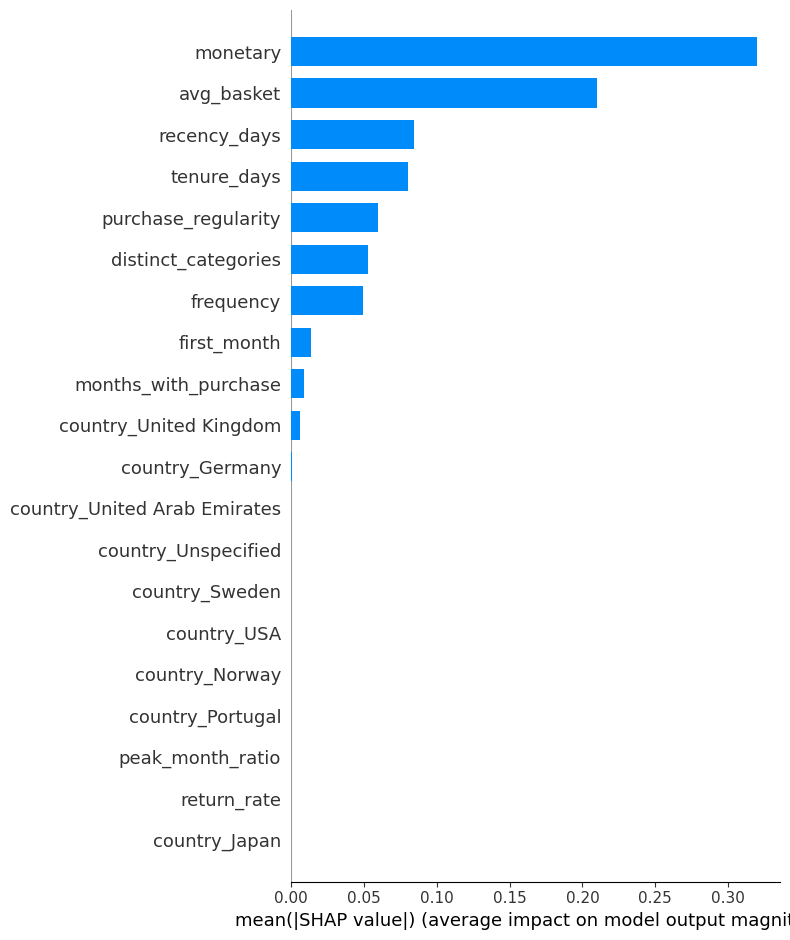


SHAP Waterfall —  Champion (CLV haute) | CLV prédit: 88.62€


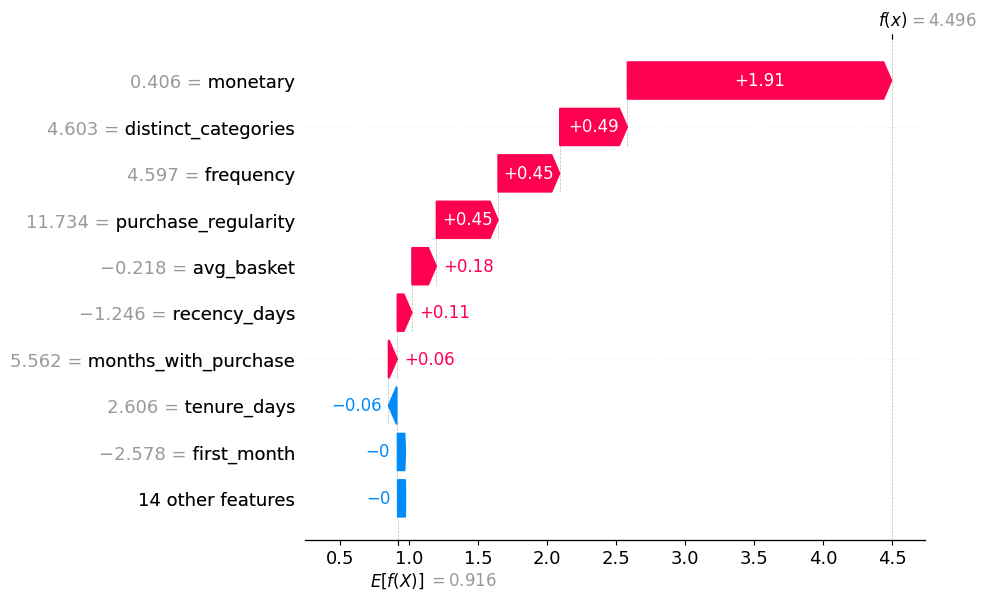


SHAP Waterfall —  À risque (CLV basse) | CLV prédit: 0.61€


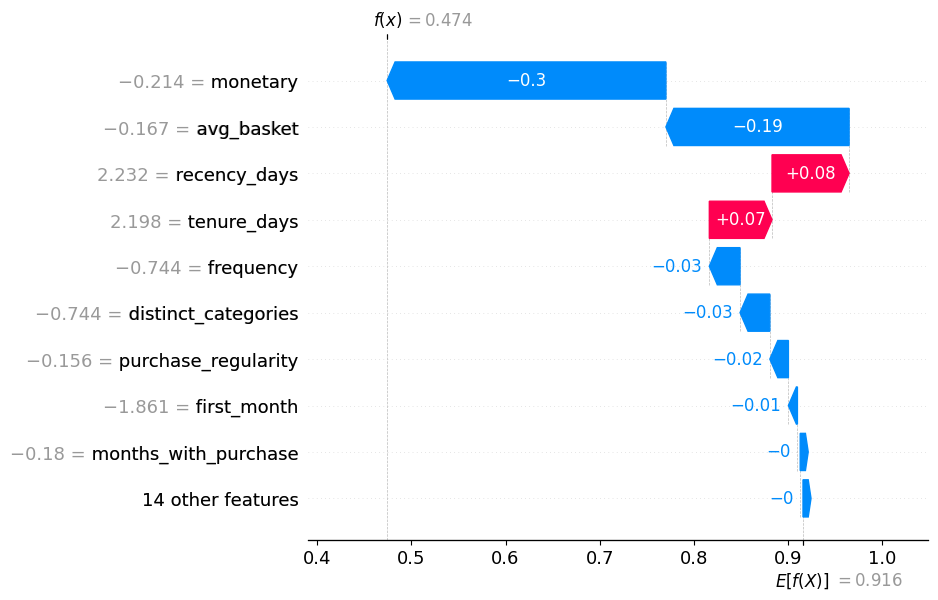

In [33]:
best_model_obj = rf_model
feat_names     = list(X.columns)

try:
    import shap
    explainer   = shap.TreeExplainer(best_model_obj)
    shap_values = explainer.shap_values(X_test_s)

    shap.summary_plot(shap_values, X_test_s, feature_names=feat_names,
                      plot_type='bar', show=True)

    pred_eur_best = np.expm1(np.clip(best_model_obj.predict(X_test_s), 0, None))
    idx_high = int(np.argmax(pred_eur_best))
    idx_low  = int(np.argmin(pred_eur_best))

    for idx, label in [(idx_high, ' Champion (CLV haute)'),
                        (idx_low,  ' À risque (CLV basse)')]:
        print(f'\nSHAP Waterfall — {label} | CLV prédit: {pred_eur_best[idx]:.2f}€')
        shap.waterfall_plot(
            shap.Explanation(values=shap_values[idx],
                             base_values=explainer.expected_value,
                             data=X_test_s[idx],
                             feature_names=feat_names), show=True)
except ImportError:
    importances = pd.Series(rf_model.feature_importances_, index=feat_names)
    importances = importances.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, max(5, len(feat_names)*0.35)))
    importances.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Feature Importance — Random Forest', fontweight='bold')
    ax.set_xlabel('Importance relative')
    plt.tight_layout()
    plt.show()
    print('\nTop 5 features:')
    print(importances.sort_values(ascending=False).head(5).round(4))

**3.6. Visualisation : Beeswarm Plot**

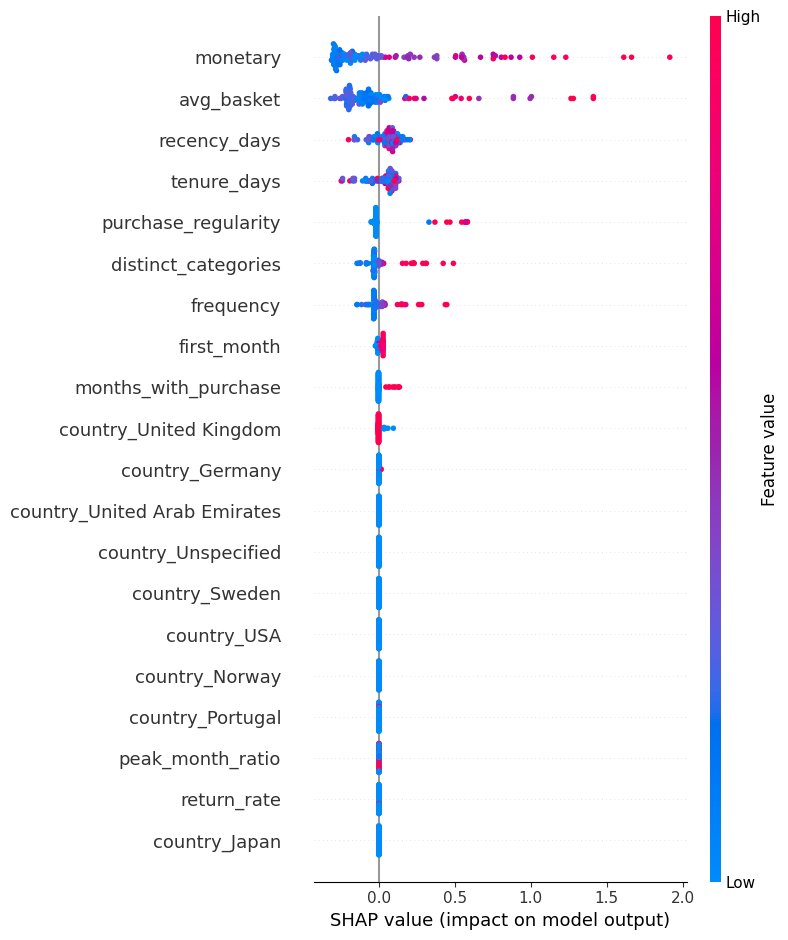

In [35]:
# Génération du graphique de synthèse (Beeswarm Plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot")

### Interprétation des variables importantes (SHAP)

**Dominance de la variable monétaire :**  
La variable **monetary** apparaît comme le facteur le plus influent dans notre modèle. Elle reflète le montant total dépensé par le client durant la période d’observation et constitue donc un indicateur direct de sa valeur économique. Les clients ayant déjà dépensé des montants élevés ont une probabilité plus forte de continuer à générer des revenus dans le futur.

**Interaction entre montant et fréquence :**  
L’analyse met également en évidence l’importance de la combinaison entre **monetary** et **frequency**. Les clients qui dépensent beaucoup et qui réalisent des achats de manière régulière présentent un comportement d’achat stable, ce qui renforce leur potentiel de valeur future.

**Indicateur de fidélité client :**  
Cette combinaison entre **montant élevé** et **fréquence d’achat élevée** peut être interprétée comme un signal fort de fidélité. Elle permet d’identifier les clients les plus stratégiques pour l’entreprise et constitue un critère pertinent pour cibler les actions de rétention ou de fidélisation marketing.


**4. Calculez le ROI potentiel d'une campagne de rétention ciblant le top 10% CLV**

In [34]:
X_all_s = scaler.transform(X)
pred_log_all = rf_model.predict(X_all_s)
pred_eur_all = np.expm1(pred_log_all)

df_res = dataset_ml[['customer_id', 'CLV_12M']].copy()
df_res['clv_predicted'] = pred_eur_all

df_res['clv_decile'] = pd.qcut(df_res['clv_predicted'], 10, labels=[f'D{i}' for i in range(1, 11)])


df_top_10 = df_res[df_res['clv_decile'] == 'D10'].copy()

nb_clients       = len(df_top_10)
cout_par_client  = 2.0
lift_reconversion = 0.15

# Calculs ROI
cout_total       = nb_clients * cout_par_client
gain_estime      = df_top_10['clv_predicted'].sum() * lift_reconversion
roi = ((gain_estime - cout_total) / cout_total) * 100

# 5. Affichage des résultats
print("--- ANALYSE DE LA SEGMENTATION ---")
summary_deciles = df_res.groupby('clv_decile')['clv_predicted'].agg(['count', 'mean', 'sum']).sort_index(ascending=False)
print(summary_deciles)
print("\n" + "="*40)
print(f'RÉSULTATS DU CHALLENGE ROI (TOP 10%)')
print(f'Nombre de clients ciblés           : {nb_clients:,}')
print(f"Coût total de l'opération (2€/clt) : {cout_total:,.2f} €")
print(f"Gain incrémental estimé (lift 15%) : {gain_estime:,.2f} €")
print(f'ROI POTENTIEL                      : {roi:.2f} %')
print("="*40)

--- ANALYSE DE LA SEGMENTATION ---
            count       mean          sum
clv_decile                               
D10            64  31.977511  2046.560733
D9             64   5.047149   323.017531
D8             64   1.892938   121.148032
D7             64   1.251876    80.120076
D6             63   0.975797    61.475220
D5             63   0.783281    49.346720
D4             65   0.640030    41.601975
D3             64   0.510106    32.646799
D2             64   0.410711    26.285508
D1             64   0.303937    19.451948

RÉSULTATS DU CHALLENGE ROI (TOP 10%)
Nombre de clients ciblés           : 64
Coût total de l'opération (2€/clt) : 128.00 €
Gain incrémental estimé (lift 15%) : 306.98 €
ROI POTENTIEL                      : 139.83 %


/tmp/ipykernel_1299/2584716237.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_deciles = df_res.groupby('clv_decile')['clv_predicted'].agg(['count', 'mean', 'sum']).sort_index(ascending=False)


### Analyse de la segmentation par déciles de CLV

Les clients ont été segmentés en 10 groupes (déciles) selon leur CLV prédite.  
On observe une forte concentration de valeur dans le décile supérieur (D10).

Le décile **D10** présente une valeur moyenne largement plus élevée que les autres segments, avec une CLV moyenne d’environ **31.98** et une somme totale de **2046.56**, ce qui montre que ces clients représentent la part la plus importante de la valeur générée.

À l’inverse, les déciles inférieurs (D1 à D4) présentent des montants moyens beaucoup plus faibles, ce qui indique des clients à faible contribution financière.

### Interprétation marketing

Cette segmentation permet d’identifier les clients les plus rentables et d’orienter les stratégies marketing.  
Les clients du décile supérieur (D10) représentent une cible prioritaire pour les campagnes de fidélisation, car leur perte aurait un impact important sur le chiffre d’affaires.

### Analyse du ROI de la campagne

Dans le cadre du challenge marketing, une campagne de rétention ciblant le **top 10 % des clients (64 clients)** a été simulée.

- Coût total de la campagne : **128 €**
- Gain incrémental estimé avec un lift de **15 %** : **306.98 €**

Le **ROI potentiel estimé est de 139.83 %**, ce qui indique que la campagne serait rentable.  
Cela confirme l’intérêt de cibler les clients à forte CLV pour maximiser l’efficacité des actions marketing.
